# Basketball Detection - Model Training

Train a YOLO26n object detector on the cleaned basketball dataset.

The model is trained incrementally in short training sessions so that development of the tracking and shot-detection pipeline can continue between training runs.

Classes:
- `basketball`
- `hoop`
- `player`

## Notebook Structure

1. Environment Setup
2. Load Final Dataset
3. Dataset Sanity Check
4. Training Hyperparameters
5. Training Strategy
6. Train Model

## 1. Environment Setup

Verify the Python environment, PyTorch, CUDA, GPU, and Ultralytics installation before training.

In [2]:
from pathlib import Path

import torch
import ultralytics
from ultralytics import YOLO


print("=" * 50)
print("ENVIRONMENT")
print("=" * 50)

print(f"PyTorch version:     {torch.__version__}")
print(f"Ultralytics version: {ultralytics.__version__}")
print(f"CUDA available:      {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU:                 {torch.cuda.get_device_name(0)}")
    print(f"CUDA version:        {torch.version.cuda}")

ENVIRONMENT
PyTorch version:     2.13.0+cu126
Ultralytics version: 8.4.138
CUDA available:      True
GPU:                 NVIDIA GeForce RTX 3050 Ti Laptop GPU
CUDA version:        12.6


## 2. Load Final Dataset

Load the cleaned development dataset and verify the dataset paths and image counts.

The external test datasets are kept separate and will only be evaluated after model development is complete.

In [3]:
from pathlib import Path
import yaml
from collections import Counter

# Main development dataset
dataset_root = Path("data/processed/basketball_dataset_final")
data_yaml_path = dataset_root / "data.yaml"

train_images = dataset_root / "train" / "images"
train_labels = dataset_root / "train" / "labels"

validation_images = dataset_root / "validation" / "images"
validation_labels = dataset_root / "validation" / "labels"

# Processed external test datasets
external_test_root = Path("data/external_test_processed")

test_04_images = external_test_root / "dataset_04_test" / "images"
test_04_labels = external_test_root / "dataset_04_test" / "labels"

test_05_images = external_test_root / "dataset_05_test" / "images"
test_05_labels = external_test_root / "dataset_05_test" / "labels"


# Load YOLO configuration
with open(data_yaml_path, "r", encoding="utf-8") as file:
    data_config = yaml.safe_load(file)

class_names = data_config["names"]


def summarize_dataset(name, images_path, labels_path):
    class_counts = Counter()
    invalid_classes = Counter()
    empty_labels = 0

    label_files = list(labels_path.glob("*.txt"))

    for label_path in label_files:

        content = label_path.read_text(
            encoding="utf-8"
        ).strip()

        if not content:
            empty_labels += 1
            continue

        for line in content.splitlines():

            parts = line.split()

            if len(parts) != 5:
                continue

            class_id = int(parts[0])

            if class_id in class_names:
                class_counts[class_id] += 1
            else:
                invalid_classes[class_id] += 1

    image_count = len([
        file for file in images_path.iterdir()
        if file.suffix.lower() in {
            ".jpg", ".jpeg", ".png", ".bmp", ".webp"
        }
    ])

    print(f"\n{name}")
    print(f"Images: {image_count}")
    print(f"Labels: {len(label_files)}")
    print(f"Empty labels: {empty_labels}")

    print("Classes:")
    for class_id, class_name in class_names.items():
        print(
            f"  {class_id} {class_name:<10}: "
            f"{class_counts[class_id]} annotations"
        )

    print(f"Invalid class IDs: {dict(invalid_classes)}")


print("YOLO classes:")
print(class_names)

summarize_dataset(
    "TRAIN",
    train_images,
    train_labels
)

summarize_dataset(
    "VALIDATION",
    validation_images,
    validation_labels
)

summarize_dataset(
    "EXTERNAL TEST 04",
    test_04_images,
    test_04_labels
)

summarize_dataset(
    "EXTERNAL TEST 05",
    test_05_images,
    test_05_labels
)

YOLO classes:
{0: 'basketball', 1: 'hoop', 2: 'player'}

TRAIN
Images: 28682
Labels: 28682
Empty labels: 0
Classes:
  0 basketball: 28568 annotations
  1 hoop      : 19905 annotations
  2 player    : 61948 annotations
Invalid class IDs: {}

VALIDATION
Images: 7171
Labels: 7171
Empty labels: 0
Classes:
  0 basketball: 7125 annotations
  1 hoop      : 5002 annotations
  2 player    : 15668 annotations
Invalid class IDs: {}

EXTERNAL TEST 04
Images: 32
Labels: 32
Empty labels: 0
Classes:
  0 basketball: 29 annotations
  1 hoop      : 32 annotations
  2 player    : 193 annotations
Invalid class IDs: {}

EXTERNAL TEST 05
Images: 4
Labels: 4
Empty labels: 0
Classes:
  0 basketball: 4 annotations
  1 hoop      : 4 annotations
  2 player    : 34 annotations
Invalid class IDs: {}


## 3. Dataset Sanity Check

Visualize random samples from the training and validation sets to verify bounding boxes and class labels before training.

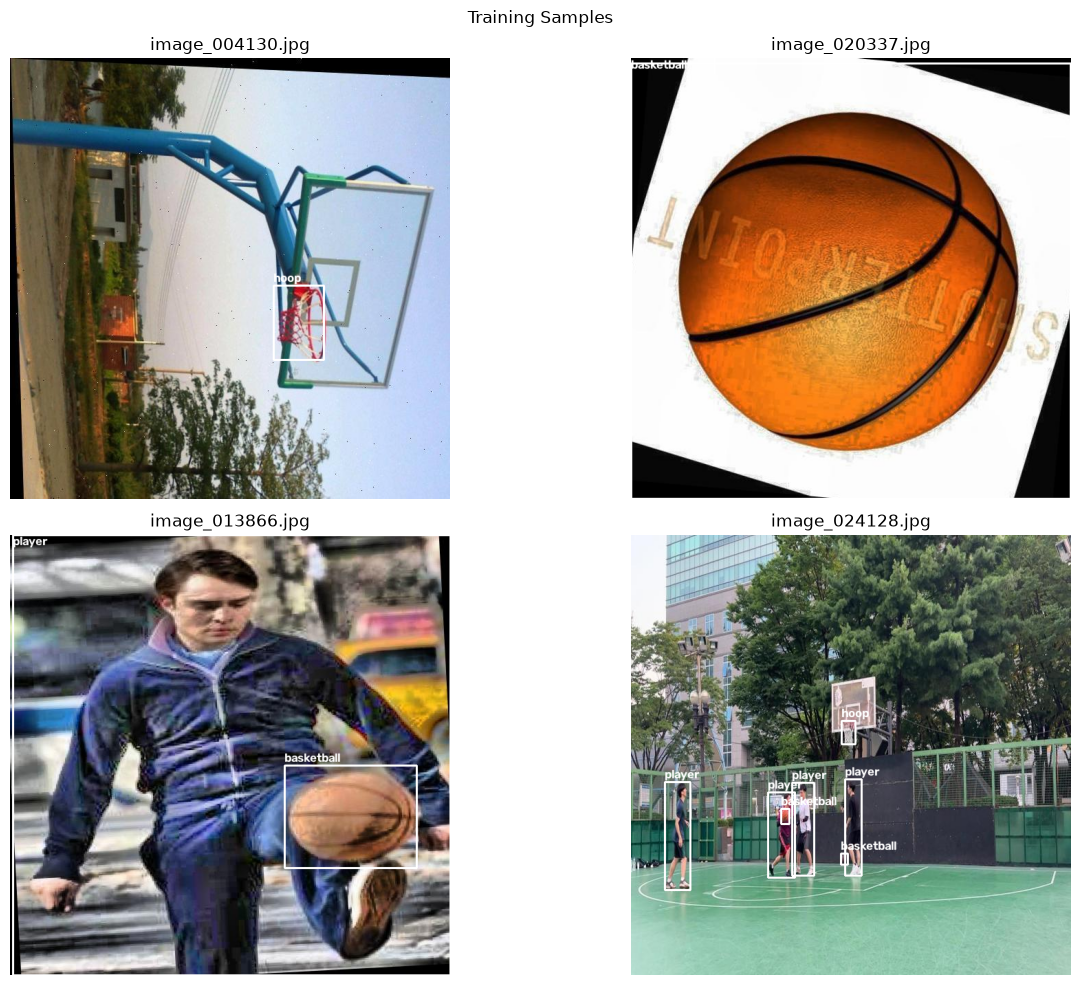

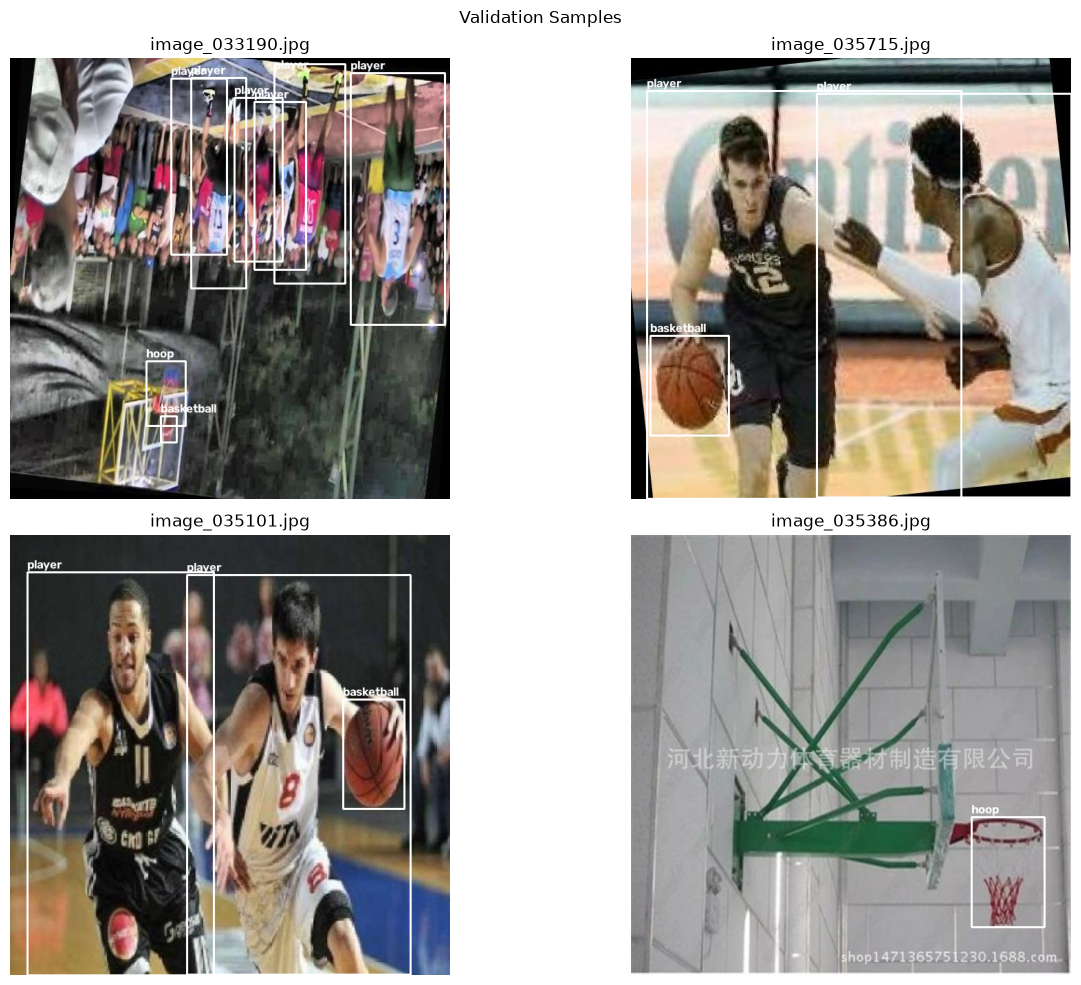

In [4]:
import random
import cv2
import matplotlib.pyplot as plt


def show_samples(images_path, labels_path, title, num_samples=4):
    image_files = [
        file for file in images_path.iterdir()
        if file.suffix.lower() in {".jpg", ".jpeg", ".png"}
    ]

    samples = random.sample(image_files, num_samples)

    plt.figure(figsize=(14, 10))

    for i, image_path in enumerate(samples, 1):

        image = cv2.imread(str(image_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        height, width = image.shape[:2]

        label_path = labels_path / f"{image_path.stem}.txt"

        with open(label_path, "r", encoding="utf-8") as file:
            for line in file:
                class_id, x, y, w, h = map(float, line.split())
                class_id = int(class_id)

                x1 = int((x - w / 2) * width)
                y1 = int((y - h / 2) * height)
                x2 = int((x + w / 2) * width)
                y2 = int((y + h / 2) * height)

                cv2.rectangle(
                    image,
                    (x1, y1),
                    (x2, y2),
                    (255, 255, 255),
                    2
                )

                cv2.putText(
                    image,
                    class_names[class_id],
                    (x1, max(y1 - 5, 15)),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6,
                    (255, 255, 255),
                    2
                )

        plt.subplot(2, 2, i)
        plt.imshow(image)
        plt.title(image_path.name)
        plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


show_samples(
    train_images,
    train_labels,
    "Training Samples"
)

show_samples(
    validation_images,
    validation_labels,
    "Validation Samples"
)

## 4. Training Hyperparameters

Review the main Ultralytics training hyperparameters that may be adjusted in later experiments.

In [5]:
from ultralytics.cfg import DEFAULT_CFG_DICT

hyperparameters = [
    "optimizer",
    "lr0",
    "lrf",
    "momentum",
    "weight_decay",
    "warmup_epochs",
    "warmup_momentum",
    "warmup_bias_lr",
    "box",
    "cls",
    "dfl",
    "hsv_h",
    "hsv_s",
    "hsv_v",
    "degrees",
    "translate",
    "scale",
    "shear",
    "perspective",
    "flipud",
    "fliplr",
    "mosaic",
    "mixup",
    "close_mosaic"
]

print("Ultralytics default hyperparameters:\n")

for parameter in hyperparameters:
    print(f"{parameter:<20}: {DEFAULT_CFG_DICT.get(parameter)}")

Ultralytics default hyperparameters:

optimizer           : auto
lr0                 : 0.01
lrf                 : 0.01
momentum            : 0.937
weight_decay        : 0.0005
warmup_epochs       : 3.0
warmup_momentum     : 0.8
warmup_bias_lr      : 0.1
box                 : 7.5
cls                 : 0.5
dfl                 : 1.5
hsv_h               : 0.015
hsv_s               : 0.7
hsv_v               : 0.4
degrees             : 0.0
translate           : 0.1
scale               : 0.5
shear               : 0.0
perspective         : 0.0
flipud              : 0.0
fliplr              : 0.5
mosaic              : 1.0
mixup               : 0.0
close_mosaic        : 10


## 5. Training Strategy

Train YOLO26n incrementally instead of running the full training process continuously.

- Maximum training target: 100 epochs
- Each training session runs for a configurable number of epochs
- Training resumes from `last.pt`
- `best.pt` stores the best model found so far
- Additional checkpoints are saved every 5 epochs
- Training stops when further validation improvement is no longer meaningful

## 6. Train Model

Train or resume YOLO26n for the selected number of epochs.

If a previous checkpoint exists, training continues from `last.pt`. Otherwise, training starts from the pretrained YOLO26n weights.

In [8]:
from pathlib import Path
from ultralytics import YOLO


# Training settings
EPOCHS_PER_RUN = 4

dataset_root = (
    Path.cwd() / "data" / "processed" / "basketball_dataset_final"
).resolve()

data_yaml_path = dataset_root / "data.yaml"

project_dir = (
    Path.cwd() / "results" / "yolo26n"
).resolve()

run_name = "baseline"

run_dir = project_dir / run_name
last_checkpoint = run_dir / "weights" / "last.pt"


training_config = {
    "data": str(data_yaml_path),
    "epochs": 100,
    "imgsz": 640,
    "batch": 16,
    "patience": 15,
    "device": 0,
    "workers": 4,
    "project": str(project_dir),
    "name": run_name,
    "save": True,
    "save_period": 5
}


class TrainingChunkComplete(Exception):
    """Stop training after the requested number of completed epochs."""
    pass


completed_this_run = 0


def stop_after_chunk(trainer):
    global completed_this_run

    completed_this_run += 1

    print(
        f"\nCompleted {completed_this_run}/{EPOCHS_PER_RUN} "
        f"epochs in this run."
    )

    if completed_this_run >= EPOCHS_PER_RUN:
        print("\nTraining chunk complete.")
        print(f"Last checkpoint: {trainer.last}")
        print(f"Best checkpoint: {trainer.best}")

        raise TrainingChunkComplete


# Prevent accidental creation of baseline2, baseline3, etc.
if run_dir.exists() and not last_checkpoint.exists():
    raise RuntimeError(
        f"Run directory exists but last.pt was not found:\n{run_dir}\n"
        "Check or remove this incomplete run before starting again."
    )


if last_checkpoint.exists():
    print("Resuming existing training:")
    print(last_checkpoint)

    model = YOLO(str(last_checkpoint))
    model.add_callback("on_fit_epoch_end", stop_after_chunk)

    try:
        model.train(resume=True)
    except TrainingChunkComplete:
        print("\nTraining paused. Run this cell again to continue.")

else:
    print("Starting new YOLO26n training.")
    print("Results will be saved to:")
    print(run_dir)

    model = YOLO("yolo26n.pt")
    model.add_callback("on_fit_epoch_end", stop_after_chunk)

    try:
        model.train(**training_config)
    except TrainingChunkComplete:
        print("\nTraining paused. Run this cell again to continue.")

Resuming existing training:
C:\Users\shaha\jupyter_notebooks\basketball_score_tracking\results\yolo26n\baseline\weights\last.pt
New https://pypi.org/project/ultralytics/8.4.161 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.138  Python-3.12.14 torch-2.13.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3050 Ti Laptop GPU, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\shaha\jupyter_notebooks\basketball_score_tracking\data\processed\basketball_dataset_final\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, 